In [7]:
import numpy as np
import matplotlib.pyplot as plt
import os
import glob

# fits = glob.glob("/scratch-cbe/users/alikaan.gueven/SBIPDF/output/toys/globalfit_shape_2_1.0_mode-poisson_N1000_scale1/*.npz")
# fits = glob.glob("/scratch-cbe/users/alikaan.gueven/SBIPDF/output/toys/toys_nominal_N10000/*.npz")
fits = glob.glob('/scratch-cbe/users/alikaan.gueven/SBIPDF/output/toys/toys-24Mar/toys_nominal_N10000/*.npz')

In [8]:
!ls /scratch-cbe/users/$USER/SBIPDF/output/toys

fit_shape_2_1.0_N100
globalfit
globalfit1
globalfit2
globalfit_shape_2_1.0_mode-poisson_N1000_scale1
toys-24Mar
toys_c2_1.0_mode-poisson_N100_scale1.npz
toys_c2_1.0_N100.npz
toys_nominal_N100
toys_nominal_N1000
toys_nominal_N200
toys_nominal_N200.npz
toys_nominal_N33_0_fit.npz
toys_nominal_N33.npz
toys_PDF4LHC21_mc_m0_rotate_N10000.json
toys_PDF4LHC21_mc_m0_rotate_N10000.npz
toys_PDF4LHC21_mc_m0_rotate_N100.json
toys_PDF4LHC21_mc_m0_rotate_N100.npz
toys_PDF4LHC21_mc_m0_rw_N1000.json
toys_PDF4LHC21_mc_m0_rw_N1000.npz
toys_rate_20.0_mode-poisson_N100_scale1.npz
toys_rate_2.0_mode-poisson_N100_scale1.npz
toys_shape_2_10.0_mode-poisson_N100_scale1.npz
toys_shape_2_1.0_mode-poisson_N1000_scale1.npz
toys_shape_2_1.0_mode-poisson_N100_scale1.npz
toys_shape_2_1.0_mode-poisson_N13_scale1.npz
toys_shape_2_1.0_N100.npz


In [9]:
# Load one fit result, and check what is inside.
# Access the individual objects like a dictionary, e.g. x['POI_names']

x = np.load(fits[0])
x.files

['config',
 'toys_npz',
 'toy_ids',
 'region_ids',
 'POI_names',
 'n2ll_min',
 'c_hat']

In [10]:
c_hats = []
n2ll_mins = []
for gf in fits:
    x = np.load(gf)
    c_hats.append(x['c_hat'])
    n2ll_mins.append(x['n2ll_min'][np.newaxis, :])
c_hats = np.concatenate(c_hats, axis=0)
n2ll_mins = np.concatenate(n2ll_mins, axis=0)

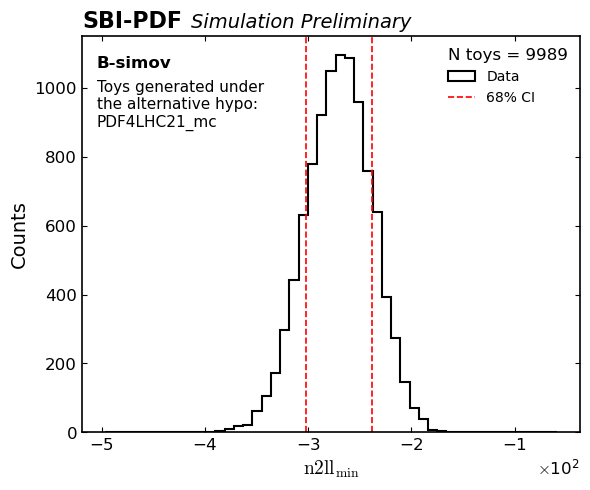

In [12]:
# WARNING
# Pay attention to change the savefig directory at the end of this code block.


# HEP-ish global style
plt.rcParams.update({
    "figure.figsize": (6, 5),
    "axes.linewidth": 1.2,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "mathtext.fontset": "cm",
})

# Calculate n_toys for the legend
n_toys = n2ll_mins.shape[0]

fig, ax = plt.subplots()

left, right = min(n2ll_mins[:, 0]), max(n2ll_mins[:, 0])
diff = right - left

# Histogram
ax.hist(
    n2ll_mins[:, 0],
    bins=np.linspace(left - diff/2, right + diff/2, 50),
    histtype="step",
    linewidth=1.5,
    color="black",
    label="Data"
)

# Calculate 68% quantiles
q16, q84 = np.percentile(n2ll_mins[:, 0], [16, 84])

# Vertical lines
ax.axvline(q16, color='red', linestyle='--', linewidth=1.2, label="68% CI")
ax.axvline(q84, color='red', linestyle='--', linewidth=1.2)

# --- 1. Text Box (Split for Bold Header) ---
ax.text(
    0.03, 0.95, 
    "B-simov", 
    transform=ax.transAxes, 
    fontsize=12, 
    weight='bold',
    verticalalignment='top'
)

body_text = (
    "Toys generated under\n"
    "the alternative hypo:\n"
    # "i.e.approximated\n"
    "PDF4LHC21_mc"
)

ax.text(
    0.03, 0.89,  # Slightly lower to sit below header
    body_text,
    transform=ax.transAxes, 
    fontsize=11,
    verticalalignment='top',
)

# --- 2. Custom Title (Split for Bold/Italic) ---
ax.text(
    0.0, 1.02, "SBI-PDF", 
    transform=ax.transAxes, 
    fontsize=16, 
    weight='bold', 
    ha='left', va='baseline'
)

ax.text(
    0.22, 1.02, "Simulation Preliminary", 
    transform=ax.transAxes, 
    fontsize=14, 
    style='italic', 
    ha='left', va='baseline'
)

import matplotlib.ticker as mtick
ax.xaxis.set_major_formatter(mtick.ScalarFormatter(useMathText=True))
ax.ticklabel_format(axis='x', style='sci', scilimits=(0, 0))

ax.set_xlabel(r"$\text{n2ll}_{{\min}}$")
ax.set_ylabel("Counts")
# ax.set_title(...) # Removed standard title

# --- 3. Legend (Aligned Left with Title) ---
ax.legend(
    title=f"N toys = {n_toys}",
    frameon=False, 
    loc="upper right",
    alignment='left',
    title_fontproperties={'size': 12}
)

plt.tight_layout()
plt.savefig('/users/alikaan.gueven/sbi-pdf/GOLLUM/user/kaan/figs/n2ll_min.pdf')
plt.savefig('/users/alikaan.gueven/sbi-pdf/GOLLUM/user/kaan/figs/n2ll_min.png')
plt.show()

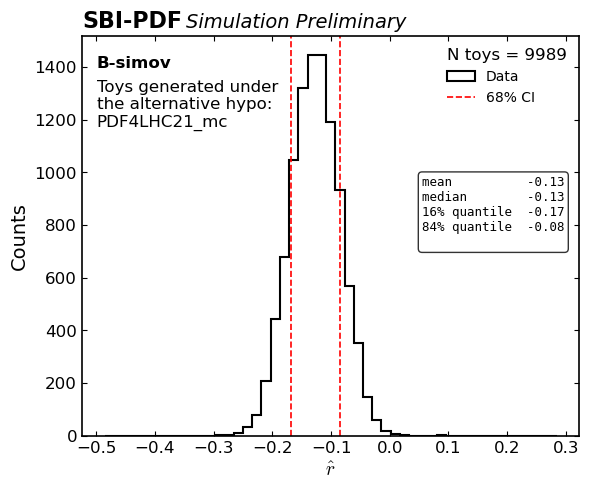

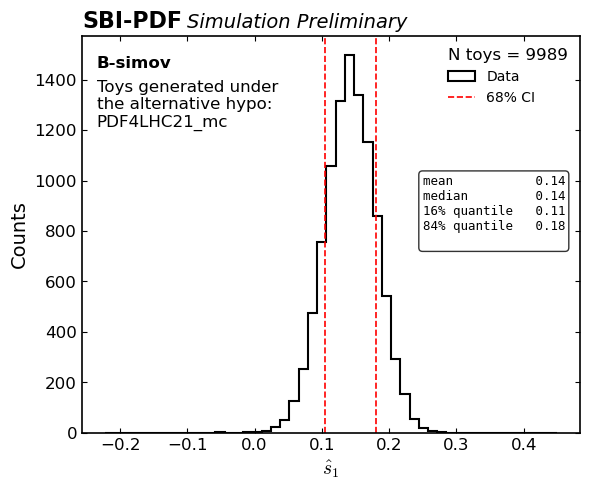

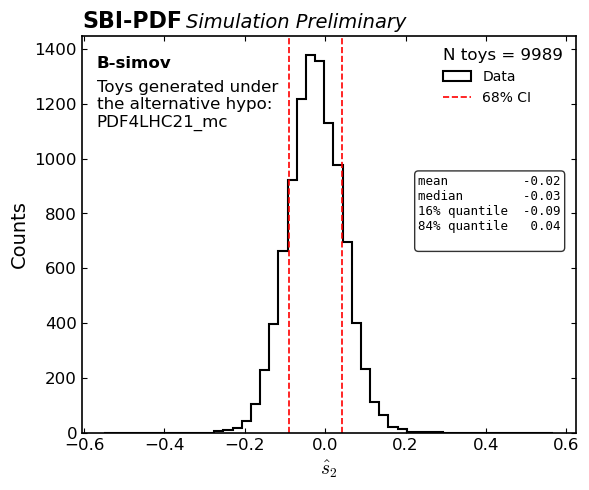

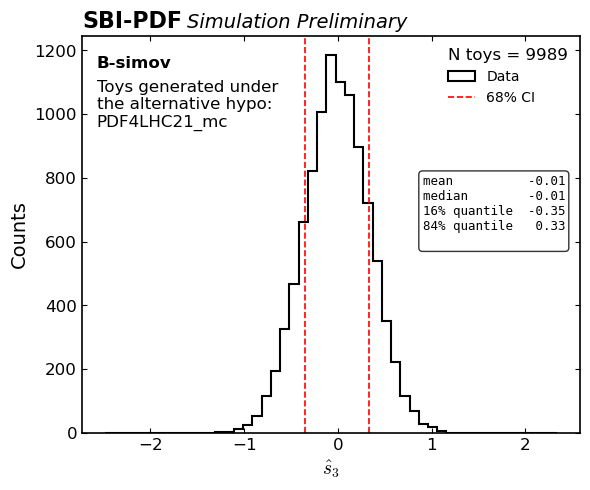

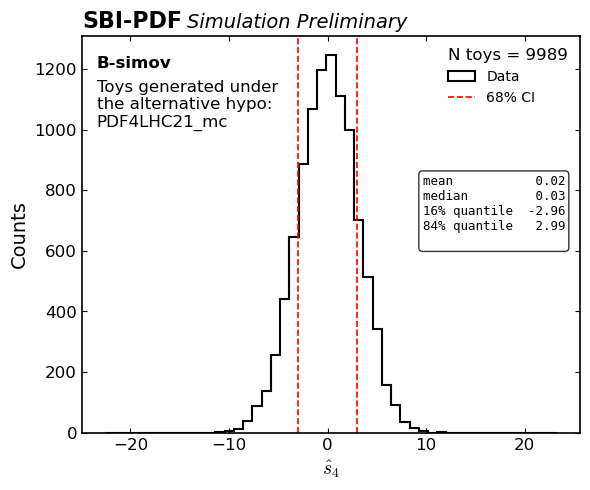

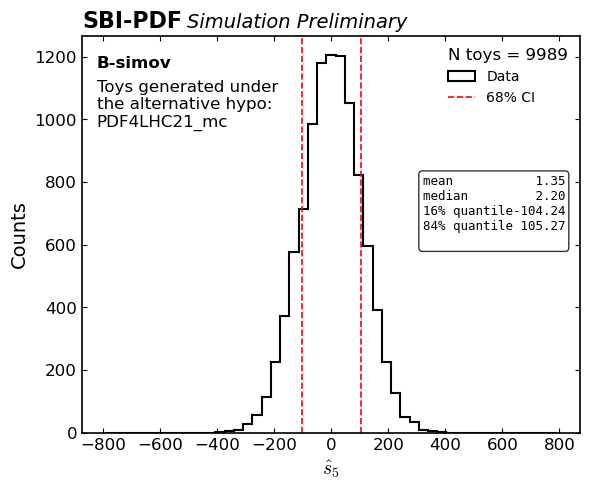

In [13]:
# WARNING
# Pay attention to change the savefig directory at the end of this code block.

# Global style tweaks (HEP-ish)
plt.rcParams.update({
    "figure.figsize": (6, 5),
    "axes.linewidth": 1.2,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "mathtext.fontset": "cm", 
})

# Assuming c_hats is defined in your environment
n_cols = c_hats.shape[1]
n_toys = c_hats.shape[0]

for i in range(n_cols):
    fig, ax = plt.subplots()

    x_min = min(c_hats[:, i])
    x_max = max(c_hats[:, i])
    x_diff = x_max - x_min
    x_lo = x_min - x_diff/2
    x_hi = x_max + x_diff/2

    ax.hist(
        c_hats[:, i],
        bins=np.linspace(x_lo, x_hi, 50),
        histtype="step",
        linewidth=1.5,
        color="black",
        label="Data"
    )

    mean = np.mean(c_hats[:, i])
    q25, q16, q50, q84, q975 = np.percentile(c_hats[:, i], [2.5, 16, 50, 84, 97.5])
    # ax.axvline(q25, color='red', linestyle=':', linewidth=1.2)
    ax.axvline(q16, color='red', linestyle='--', linewidth=1.2, label="68% CI")
    ax.axvline(q84, color='red', linestyle='--', linewidth=1.2)
    # ax.axvline(q975, color='red', linestyle=':', linewidth=1.2, label="95% CI")

    Wlab = 12
    Wnum = 7  # room for sign + digits + dot

    stats_text = (
        f"{'mean':<{Wlab}}{mean:>{Wnum}.2f}\n"
        f"{'median':<{Wlab}}{q50:>{Wnum}.2f}\n"
        f"{'16% quantile':<{Wlab}}{q16:>{Wnum}.2f}\n"
        f"{'84% quantile':<{Wlab}}{q84:>{Wnum}.2f}\n"
    )



    ax.text(
        0.97, 0.65, stats_text,
        transform=ax.transAxes,
        fontsize=9,
        ha="right", va="top",
        fontfamily="DejaVu Sans Mono",   # <-- key
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8)
    )


    ax.text(
        0.03, 0.95, 
        "B-simov", 
        transform=ax.transAxes, 
        fontsize=12, 
        weight='bold',
        verticalalignment='top'
    )
    
    body_text = (
    "Toys generated under\n"
    "the alternative hypo:\n"
    # "i.e.approximated\n"
    "PDF4LHC21_mc"
)
    
    ax.text(
        0.03, 0.89,
        body_text,
        transform=ax.transAxes, 
        fontsize=12,
        verticalalignment='top',
    )

    if i == 0:
        ax.set_xlabel(rf"$\hat{{r}}$")
    else:
        ax.set_xlabel(rf"$\hat{{s}}_{i}$")
    ax.set_ylabel("Counts")
    
    ax.text(
        0.0, 1.02, "SBI-PDF", 
        transform=ax.transAxes, 
        fontsize=16, 
        weight='bold', 
        ha='left', va='baseline'
    )
    
    ax.text(
        0.21, 1.02, "Simulation Preliminary", 
        transform=ax.transAxes, 
        fontsize=14, 
        style='italic', 
        ha='left', va='baseline'
    )

    ax.legend(
        title=f"N toys = {n_toys}",
        frameon=False,
        alignment='left',
        title_fontproperties={'size': 12}
    )

    plt.tight_layout()
    plt.savefig(f'/users/alikaan.gueven/sbi-pdf/GOLLUM/user/kaan/figs/toy_fits_c_{i}.pdf')
    plt.savefig(f'/users/alikaan.gueven/sbi-pdf/GOLLUM/user/kaan/figs/toy_fits_c_{i}.png')
    plt.show()

In [29]:
Wlab = 15
Wnum = 10  # room for sign + digits + dot

stats_text = (
    f"{'mean':<{Wlab}}{mean:>{Wnum}.2f}\n"
    f"{'16% quantile':<{Wlab}}{q16:>{Wnum}.2f}\n"
    f"{'median':<{Wlab}}{q50:>{Wnum}.2f}\n"
    f"{'84% quantile':<{Wlab}}{q84:>{Wnum}.2f}\n"
)
print(stats_text)

mean                -0.01
16% quantile        -0.90
median              -0.02
84% quantile         0.88

